In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [24]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
df.shape

(400, 5)

In [ ]:
df.drop("User ID", axis=1)

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
...,...,...,...,...
395,Female,46,41000,1
396,Male,51,23000,1
397,Female,50,20000,1
398,Male,36,33000,0


In [ ]:
print("Purchased Count : ", df['Purchased'].value_counts())

Purchased Count :  Purchased
0    257
1    143
Name: count, dtype: int64


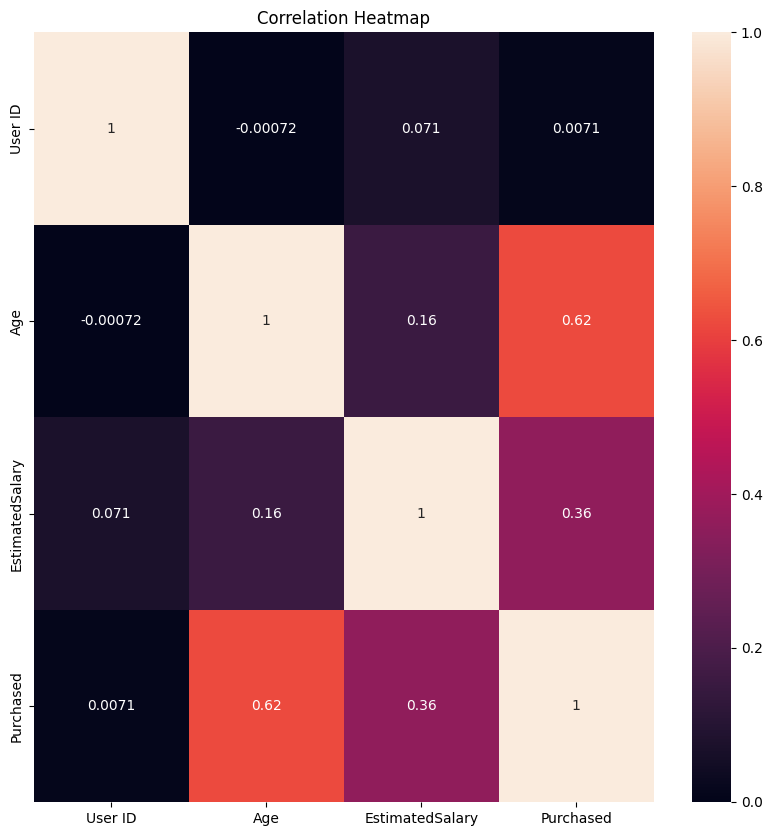

In [ ]:
import seaborn as sns

# Converting gender to numeric value
df['Gender'] = df['Gender'].map({0:"Male", 1:"Female"})

# select numeric column
df_numeric = df.select_dtypes(include=["int64", "float64"])

corr = df_numeric.corr()

plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
df.groupby('Purchased')[["Age","EstimatedSalary"]].mean()

,Age,EstimatedSalary
Purchased,,
0,32.793774,60544.747082
1,46.391608,86272.727273


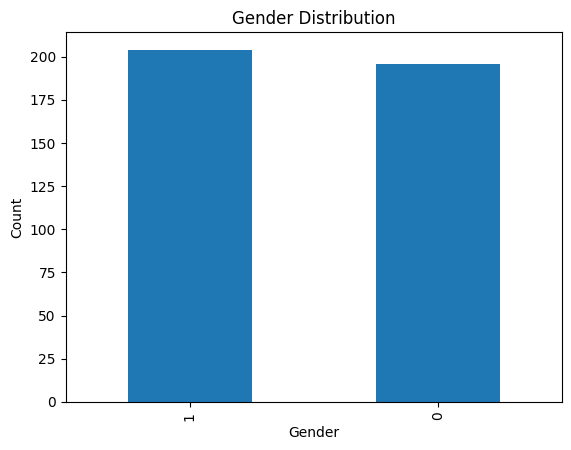

In [28]:
df['Gender_Label'] = df['Gender'].map({'Male':0, 'Female':1})

df['Gender_Label'].value_counts().plot(kind='bar')

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

In [29]:
X = df[['Age','EstimatedSalary']]
y = df['Purchased']

In [30]:
from sklearn.preprocessing import StandardScaler

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Scale the data
sc = StandardScaler()
X = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [31]:
model = LogisticRegression()
model.fit(X_train, y_train)
print("Model Trained")

Model Trained


In [33]:
# Predictions
y_pred = model.predict(X_test)
print("Training Accuracy :  {:.2f}%".format(model.score(X_train, y_train)))
print("Testing Accuracy : {:.2f}%".format(model.score(X_test, y_test)))

Training Accuracy :  0.83%
Testing Accuracy : 0.63%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [34]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix : ",cm)

Confusion Matrix :  [[63  0]
 [37  0]]


In [35]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("True Negative : ", TN)
print("False Positive : ", FP)
print("False Negative : ", FN)
print("True Positive : ", TP)

True Negative :  63
False Positive :  0
False Negative :  37
True Positive :  0


In [36]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP)
recall = TP / (TP + FP)
error_rate = 1 - accuracy
f1_score = 2* (precision*recall)/(precision+recall)

print("Accuracy : ", accuracy)
print("Precision : ", precision)
print("Recall : ", recall)
print("Error Rate : ", error_rate)
print("F1 Score : ", f1_score)

Accuracy :  0.63
Precision :  nan
Recall :  nan
Error Rate :  0.37
F1 Score :  nan


/tmp/ipykernel_1015/2940746727.py:2: RuntimeWarning: invalid value encountered in scalar divide
  precision = TP / (TP + FP)
/tmp/ipykernel_1015/2940746727.py:3: RuntimeWarning: invalid value encountered in scalar divide
  recall = TP / (TP + FP)


In [37]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      1.00      0.77        63
           1       0.00      0.00      0.00        37

    accuracy                           0.63       100
   macro avg       0.32      0.50      0.39       100
weighted avg       0.40      0.63      0.49       100



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
